In [2]:
%load_ext autoreload
%autoreload 2
import os,sys

default_n_threads = 8
os.environ['OPENBLAS_NUM_THREADS'] = f"{default_n_threads}"
os.environ['MKL_NUM_THREADS'] = f"{default_n_threads}"
os.environ['OMP_NUM_THREADS'] = f"{default_n_threads}"

import torch
import numpy as np
import pandas as pd
import scanpy as sc
import PINN
from PINN import reader, models
from torchdiffeq import odeint
from TorchDiffEqPack.odesolver import odesolve
from torchdyn.core import NeuralODE
import matplotlib.pyplot as plt
from matplotlib import cm

In [3]:
os.chdir("/ssd/users/Wergillius/Project/PINN_dynamics")

In [4]:
adata = sc.read_h5ad(f"data/tom_pos.h5ad")

In [5]:
adata

AnnData object with n_obs × n_vars = 49390 × 4814
    obs: 'n_genes', 'n_counts', 'mt_count', 'mt_frac', 'doublet_scores', 'predicted_doublets', 'xist_logn', 'Ygene_logn', 'xist_bin', 'Ygene_bin', 'sex_adata', 'biosample_id', 'cellid', 'RBG', 'SLXid', 'index', '10xsample_description', 'sex_mixed', 'sex_meta', 'mouse_id', 'sortedcells', 'expected_cells_10x', 'cellranger_cellsfound', 'chemistry', 'tom', 'expdate', 'batch', 'timepoint_tx_days', 'start_age', 'sample_id', 'countfile', 'S_score', 'G2M_score', 'phase', 'leiden', 'SLX', 'plate_sorted', 'plate_rearranged', 'well_sorted', 'well_rearranged', 'set_index', 'CI_index', 'mouse_platelabel', 'sort_method', 'sample.name', 'population', 'sex', 'countfolder', 'batch_plate_sorted', 'data_type', 'sex_combined', 'longname', 'anno_man', 'leiden_DM', 'HSCscore', 'nn_HSCscore', 'isroot', 'dpt_pseudotime', 'leiden_orig', 'logk', 'net_prolif', 'log10SR', 'log_density_at_E3', 'log_density_at_E7', 'log_density_at_E12', 'log_density_at_E12_clip', 'l

In [6]:
celltype_pallete = {"HSC":"#E278C6","Meg":"#AFC7E5","Mono/DC prog":"#FFC58B",
 "Int prog":"#C8C8C8","Ery":"#8C554A","Eos":"#AD40FC",
 "Neu":"#9BDD91","Bas/MC prog":"#279F6A","Ly":"#31C6D3"}

In [7]:
adata.uns['anno_man_colors'] = [celltype_pallete[ct] for ct in adata.obs.anno_man.cat.categories]

# density estimate

In [8]:
device = 'cuda:2'

In [9]:
config = PINN.ExperimentConfig(config=f"logs/tompos_leavout_t5n7/pde_params_tsense/V0_config.json")


config.dataset_config['timepoint_idx'] = 9
DS_full = PINN.reader.TwoTimpepoint_AnnDS(AnnData=adata, **config.dataset_config)
DS_full.cellstate.shape

Computing density :
`density_funs` not specified, use gaussian kde


(49390, 10)

In [ ]:
inv_model_dict = {}
tv_model_dict = {}

for v in range(4):
    # time-invariant model
    config_inv = PINN.ExperimentConfig(config=f"logs/tompos_leavout_t5n7/pde_params/V{v}_config.json")
    model_inv = PINN.models.pde_params.load_from_checkpoint(config_inv.find_lastest_ckpt()).to(device)
    inv_model_dict[str(v)] = PINN.tl.density_shortterm_simulation(model_inv, DS_full)

    # time-variable
    config_tv = PINN.ExperimentConfig(config=f"logs/tompos_leavout_t5n7/pde_params_tsense/V{v}_config.json")
    model_tv = PINN.models.pde_params.load_from_checkpoint(config_tv.find_lastest_ckpt()).to(device)
    tv_model_dict[str(v)] = PINN.tl.density_shortterm_simulation(model_tv, DS_full)

pde_model = PINN.models.pde_params.load_from_checkpoint("logs/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/pde_params_tsense/lightning_logs/version_4/checkpoints/epoch=95-total_loss=1.33532071.ckpt")
tv_model_dict['best'] = PINN.tl.density_shortterm_simulation(pde_model.to(device), DS_full)

del model_inv , model_tv, pde_model

In [ ]:
# dudt, ds, duds_by_time, growth, drift, diffuse 
out_ls = PINN.tl.density_shortterm_simulation(pde_model.to(device), DS_full, return_all=True)

0it [00:00, ?it/s]

simulating from timepoint 3 to 7
simulating from timepoint 7 to 12
simulating from timepoint 12 to 27
simulating from timepoint 27 to 49
simulating from timepoint 49 to 76
simulating from timepoint 76 to 112
simulating from timepoint 112 to 161
simulating from timepoint 161 to 269


In [ ]:
try:

    tv_growth = np.load("results/tompos_leavout_t5n7/pde_params_tsense/sim_growth_Mar4.npy")
    inv_growth = np.load("results/tompos_leavout_t5n7/pde_params/sim_growth_Mar4.npy")

    tv_model_dict = np.load("results/tompos_leavout_t5n7/pde_params_tsense/sim_density_Mar4.npy",allow_pickle=True).item()
    inv_model_dict = np.load("results/tompos_leavout_t5n7/pde_params/sim_density_Mar4.npy",allow_pickle=True).item()

except:
    # to store the density
    inv_model_dict = {}
    tv_model_dict = {}
    inv_growth = {}
    tv_growth = {}

    for v in range(4):
        # time-invariant model
        config_inv = PINN.ExperimentConfig(config=f"logs/tompos_leavout_t5n7/pde_params/V{v}_config.json")
        model_inv = PINN.models.pde_params.load_from_checkpoint(config_inv.find_lastest_ckpt()).to(device)
        
        out_ls = PINN.tl.density_shortterm_simulation(model_inv, DS_full, return_all=True)
        inv_model_dict[str(v)] = out_ls[0]
        inv_growth[str(v)] = out_ls[3]

        # time-variable
        config_tv = PINN.ExperimentConfig(config=f"logs/tompos_leavout_t5n7/pde_params_tsense/V{v}_config.json")
        model_tv = PINN.models.pde_params.load_from_checkpoint(config_tv.find_lastest_ckpt()).to(device)
        
        out_ls = PINN.tl.density_shortterm_simulation(model_tv, DS_full, return_all=True)
        tv_model_dict[str(v)] = out_ls[0]
        tv_growth[str(v)] = out_ls[3]

    pde_model = PINN.models.pde_params.load_from_checkpoint("logs/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/pde_params_tsense/lightning_logs/version_4/checkpoints/epoch=95-total_loss=1.33532071.ckpt")
    
    out_ls = PINN.tl.density_shortterm_simulation(pde_model.to(device), DS_full, return_all=True)
    tv_model_dict['best'] = out_ls[0]
    tv_growth['best'] = out_ls[3]

    del model_inv , model_tv, pde_model

    ### save the params
    # PINN.tl.make_dir("results/tompos_leavout_t5n7/pde_params_tsense")
    # PINN.tl.make_dir("results/tompos_leavout_t5n7/pde_params")

    # np.save("results/tompos_leavout_t5n7/pde_params_tsense/sim_density_Mar4.npy",tv_model_dict)
    # np.save("results/tompos_leavout_t5n7/pde_params/sim_density_Mar4.npy",inv_model_dict)

0it [00:00, ?it/s]

simulating from timepoint 3 to 7
simulating from timepoint 7 to 12
simulating from timepoint 12 to 27
simulating from timepoint 27 to 49
simulating from timepoint 49 to 76
simulating from timepoint 76 to 112
simulating from timepoint 112 to 161
simulating from timepoint 161 to 269


0it [00:00, ?it/s]

simulating from timepoint 3 to 7
simulating from timepoint 7 to 12
simulating from timepoint 12 to 27
simulating from timepoint 27 to 49
simulating from timepoint 49 to 76
simulating from timepoint 76 to 112
simulating from timepoint 112 to 161
simulating from timepoint 161 to 269


0it [00:00, ?it/s]

...

0it [00:00, ?it/s]

simulating from timepoint 3 to 7
simulating from timepoint 7 to 12
simulating from timepoint 12 to 27
simulating from timepoint 27 to 49
simulating from timepoint 49 to 76
simulating from timepoint 76 to 112
simulating from timepoint 112 to 161
simulating from timepoint 161 to 269


/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/migration/utils.py:49: PossibleUserWarning: The loaded checkpoint was produced with Lightning v2.3.0, which is newer than your current Lightning version: v1.9.5
  rank_zero_warn(


0it [00:00, ?it/s]

simulating from timepoint 3 to 7
simulating from timepoint 7 to 12
simulating from timepoint 12 to 27
simulating from timepoint 27 to 49
simulating from timepoint 49 to 76
simulating from timepoint 76 to 112
simulating from timepoint 112 to 161
simulating from timepoint 161 to 269


In [ ]:
np.save("results/tompos_leavout_t5n7/pde_params_tsense/sim_growth_Mar4.npy",tv_growth)
np.save("results/tompos_leavout_t5n7/pde_params/sim_growth_Mar4.npy", inv_growth)

np.save("results/tompos_leavout_t5n7/pde_params_tsense/sim_density_Mar4.npy",tv_model_dict)
np.save("results/tompos_leavout_t5n7/pde_params/sim_density_Mar4.npy",inv_model_dict)

In [153]:
for i in range(4):
    print(DS_full.popD['mean'][1:] - np.sum(tv_growth[str(i)][np.arange(1,16,2)] + u_b[:-1], axis=1))

[ 1.69364338e+00  1.14716295e+00  5.28302026e+00 -1.04676210e-01
  1.31468485e+01 -1.26253563e+01 -6.64705087e+01 -1.75478574e+02]
[  1.62213832   0.28751448   3.68398261  -0.48840233  16.92233069
   2.73063129 -32.56268708 -92.32439931]
[ 1.35161787  0.23617915  3.81755424  5.17832664 28.83929427 23.30329364
  4.63279327 22.27273814]
[ 1.27607864  0.77717045  3.23558021 -6.80201431 15.8088053   7.20319598
 -3.3489267   5.31845348]


In [140]:
np.sum(inv_growth['2'][np.arange(1,16,2)] + u_b[:-1], axis=1)

array([  1.1677008,   3.2489157,   8.338886 ,  26.58397  ,  55.434032 ,
       131.87927  , 249.90083  , 626.1854   ], dtype=float32)

array([  2.64384835,   3.92308095,  12.56231284,  21.24678711,
        56.01314719,  94.89488452, 133.58129486, 283.82983653])

In [ ]:
tv_model_dict['0'].shape

(8, 49390)

# evaluate the imputed density

In [8]:
config = PINN.ExperimentConfig(config=f"logs/tompos_leavout_t5n7/pde_params_tsense/V0_config.json")


config.dataset_config['timepoint_idx'] = 9
DS_full = PINN.reader.TwoTimpepoint_AnnDS(AnnData=adata, **config.dataset_config)
DS_full.cellstate.shape

Computing density :
`density_funs` not specified, use gaussian kde


(49390, 10)

In [11]:
import mellon

TM1=[0,1,2,3,4,6,8]

cellstate_key = 'DM_scaled'
timepoint_key = 'timepoint_tx_days'
timepoints = adata.uns['pop']['t'][TM1]
adata_TM1 = adata[adata.obs.query(f"`{timepoint_key}` in @timepoints").index]

In [12]:
if not os.path.exists(f"data/tom_pos_mellon_TM1_predictor.json"):
    X = adata_TM1.obsm[cellstate_key][:,:10]
    X_times = adata_TM1.obs[timepoint_key].astype(int).apply(np.log)
    ls_time_estimate = 1.5 * np.mean(np.diff(np.log(timepoints)))
    t_est = mellon.TimeSensitiveDensityEstimator(d=2, ls_time=ls_time_estimate)
    # Fit the estimator to the data
    t_est.fit(X, X_times)
    t_pred = t_est.predict
    t_pred.to_json(f"data/tom_pos_mellon_TM1_predictor.json") 
else:
    t_pred = mellon.Predictor.from_json(f"data/tom_pos_mellon_TM1_predictor.json")

An NVIDIA GPU may be present on this machine, but a CUDA-enabled jaxlib is not installed. Falling back to cpu.


In [13]:
X = DS_full.cellstate
log_u_mellon = np.stack([t_pred(X, np.full((X.shape[0],), np.log(t))) for t in DS_full.popD['t']])

In [14]:
u_mellon = np.exp(log_u_mellon)

In [15]:
u_b = DS_full.u_b.numpy()

timepoint_mask = [DS_full.adata.obs[DS_full.timepoint_key] == t for t in DS_full.popD['t']]
u_b_t = [u[msk] for u, msk in zip(DS_full.u_b.numpy(), timepoint_mask)]

u_intepolate = (u_b[:-1] + u_b[1:]) /2

In [16]:
u_intepolate.shape

(8, 49390)

In [17]:
from PINN.functions import eval_funs as ef

In [18]:
def eval_metrics(u_sim):
    js = {
        "KLDs":ef.KLD_density(u_b_t[1:], u_sim, sanity_check=False),
        "W_distance": ef.W_distance(u_b_t[1:],u_sim, log_transform=False),
        "W_log_distance": ef.W_log_distance(u_b_t[1:],u_sim, log_transform=False),
        "timepoint" : DS_full.popD['t'][1:]
     }
    df = pd.DataFrame(js)
    return df

df_ls = []
for v in inv_model_dict:
    u_sim = [u[msk] for u, msk in zip(inv_model_dict[str(v)], timepoint_mask[1:])]
    df = eval_metrics(u_sim)
    df['model'] = f'inv_{v}'
    df_ls.append(df)

for v in tv_model_dict:
    u_sim = [u[msk] for u, msk in zip(tv_model_dict[str(v)], timepoint_mask[1:])]
    df = eval_metrics(u_sim)
    df['model'] = f'tv_{v}'
    df_ls.append(df)

u_sim = [u[msk] for u, msk in zip(u_mellon[1:], timepoint_mask[1:])]
df = eval_metrics(u_sim)
df['model'] = 'mellon'
df_ls.append(df)

u_sim = [u[msk] for u, msk in zip(u_intepolate, timepoint_mask[1:])]
df = eval_metrics(u_sim)
df['model'] = 'intepolate'
df_ls.append(df)

In [ ]:
# model_compare =['inv_0', 'tv_best', 'mellon', 'intepolate']
perform_df = pd.concat(df_ls).astype({"timepoint":"str"})#.query("`model` in @model_compare")

In [20]:
import seaborn as sns

In [160]:
model_compare =['tv_0', 'tv_1','tv_2','tv_3']
perform_df = pd.concat(df_ls).astype({"timepoint":"str"}).query("`model` in @model_compare")

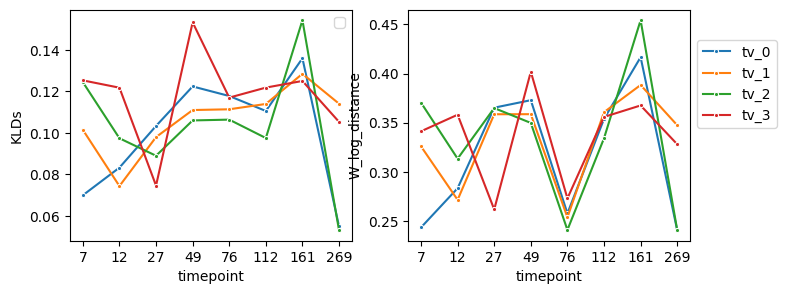

In [164]:
fig, axs= plt.subplots(1,2, figsize=(8,3))
sns.lineplot(data=perform_df, x='timepoint', y='KLDs', hue='model', marker='.', ax=axs[0])
sns.lineplot(data=perform_df, x='timepoint', y='W_log_distance', hue='model', marker='.', ax=axs[1])
axs[0].legend([])
axs[1].legend(bbox_to_anchor=[1,0.9])
# g.set_ylim(-0.01, 0.25)

<Axes: xlabel='timepoint', ylabel='W_log_distance'>

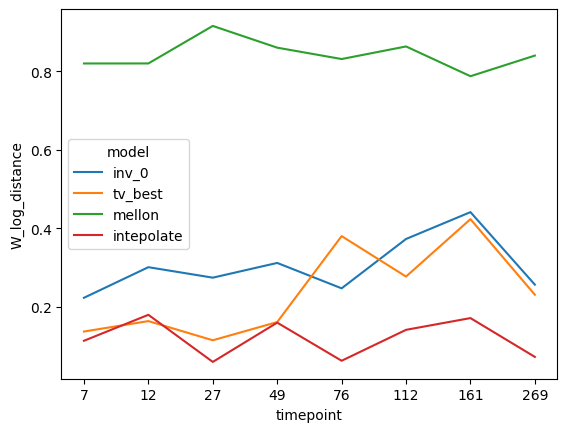

In [ ]:
sns.lineplot(data=perform_df.query("`model` in @model_compare"), 
                    x='timepoint', y='W_log_distance', hue='model')

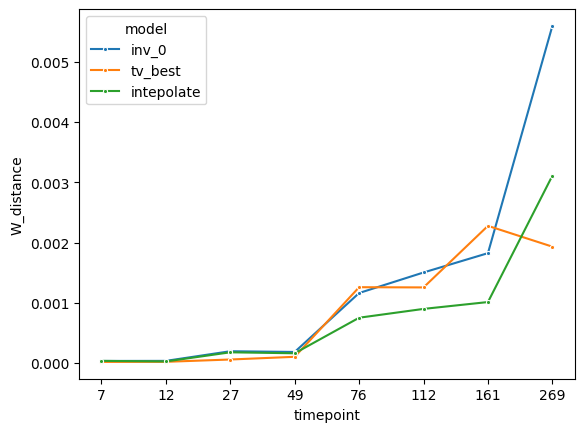

In [ ]:
model_compare =['inv_0', 'tv_best',  'intepolate']
g = sns.lineplot(data=perform_df.query("`model` in @model_compare"), x='timepoint', y='W_distance', hue='model', marker='.')
# g.set_ylim(-0.01, 0.25)

# try new metric MMD

In [ ]:
mmds = []
for u, u_sim in zip(u_b[1:], tv_model_dict['best']):
    mmd = PINN.tl.mmd_laplace(u, u_sim)
    mmds.append(mmd)

heuristic gamma 20714.688334861876
computing K<XX>
computing K<YY>
computing K<XY>
heuristic gamma 13742.598045944464
computing K<XX>
computing K<YY>
computing K<XY>
heuristic gamma 4581.750820597687
computing K<XX>
computing K<YY>
computing K<XY>
heuristic gamma 3365.9070951628332
computing K<XX>
computing K<YY>
computing K<XY>
heuristic gamma 1512.6218765176961
computing K<XX>
computing K<YY>
computing K<XY>
heuristic gamma 558.2482253062801
computing K<XX>
computing K<YY>
computing K<XY>
heuristic gamma 404.83445735840064
computing K<XX>
computing K<YY>
computing K<XY>
heuristic gamma 243.38938052595853
computing K<XX>
computing K<YY>
computing K<XY>


In [ ]:
mmds

[0.07136653170416149,
 0.09049548426831534,
 0.051065800667964165,
 0.0985698018941668,
 0.2960446781823536,
 0.1990318853084758,
 0.20645732401489642,
 0.17083207280841828]

In [ ]:
gamma=[  
    20714.688334861876,
    13742.598045944464,
    4581.750820597687,
    3365.9070951628332,
    1512.6218765176961,
    558.2482253062801,
    404.83445735840064,
    243.38938052595853
]

In [ ]:
fix_gamma_mmds = []
for u, u_sim in zip(u_b[1:], tv_model_dict['best']):
    mmd = PINN.tl.mmd_laplace(u, u_sim, gamma=500)
    fix_gamma_mmds.append(mmd)
fix_gamma_mmds

computing K<XX>
computing K<YY>
computing K<XY>
computing K<XX>
computing K<YY>
computing K<XY>
computing K<XX>
computing K<YY>
computing K<XY>
computing K<XX>
computing K<YY>
computing K<XY>
computing K<XX>
computing K<YY>
computing K<XY>
computing K<XX>
computing K<YY>
computing K<XY>
computing K<XX>
computing K<YY>
computing K<XY>
computing K<XX>
computing K<YY>
computing K<XY>


[0.016024215184012865,
 0.019947605399365975,
 0.02276983212421196,
 0.04565184861339947,
 0.24370861413705674,
 0.19795557657921073,
 0.2079204692321248,
 0.18117702222214915]

In [ ]:
[PINN.tl.mmd_laplace(u_b[1], tv_model_dict['best'][0], gamma=500)]

computing K<XX>
computing K<YY>
computing K<XY>


0.000241544665282729

In [ ]:
PINN.tl.mmd_laplace(u_b[1], tv_model_dict['best'][0])

computing K<XX>
computing K<YY>
computing K<XY>


0.0

# time inv growth

In [62]:
device = 'cuda:2'

In [63]:
v = 0
config_inv = PINN.ExperimentConfig(config=f"logs/tompos_leavout_t5n7/pde_params/V{v}_config.json")
pde_inv = PINN.models.pde_params.load_from_checkpoint(config_inv.find_lastest_ckpt()).to(device)

config_inv.dataset_config['timepoint_idx'] = 9
DS_full = PINN.reader.TwoTimpepoint_AnnDS(AnnData=adata, **config_inv.dataset_config)
DS_full.cellstate.shape

Computing density :
`density_funs` not specified, use gaussian kde


(49390, 10)

In [64]:
v_inv, g_inv, D_inv = pde_inv.predict_param(DS_full)

In [65]:
dm_ranges = v_inv[0].max(axis=1) - v_inv[0].min(axis=1)
dm_ranges = dm_ranges.reshape(-1,1)

v_inv_norm = np.power(v_inv/dm_ranges,2).sum(axis=-1)**0.5

In [66]:
adata.obs['growth_inv'] = g_inv[0] /3
adata.obs['drift_norm_inv'] = v_inv_norm[0] / 3

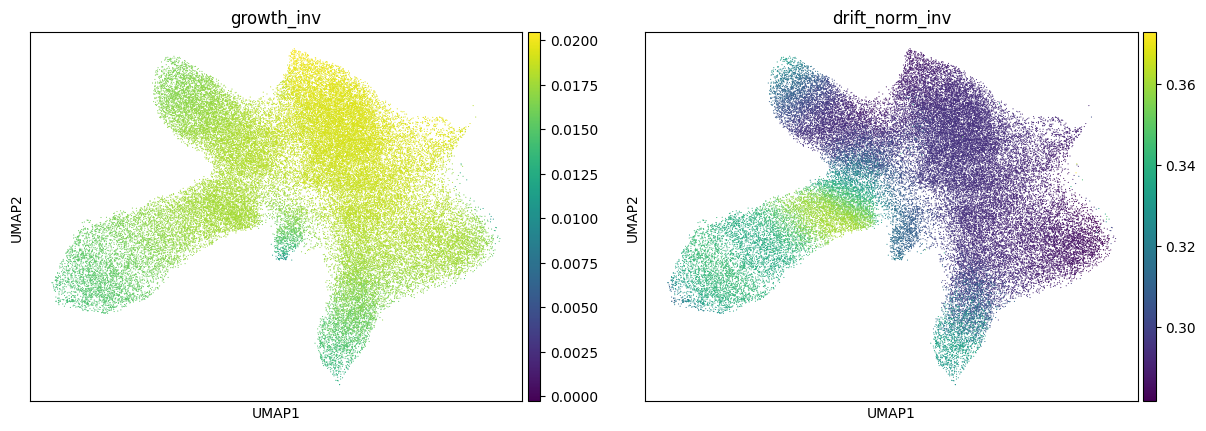

In [67]:
sc.pl.umap(adata, color=['growth_inv','drift_norm_inv'])

In [68]:
inv_param = adata.obs.groupby(['anno_man', 'timepoint_tx_days']).agg({"growth_inv":'mean', 'batch':'count'}).reset_index()
inv_param = inv_param.sort_values('timepoint_tx_days').query("`batch` >= 15").astype({"timepoint_tx_days":"str"})

In [69]:
import seaborn as sns

/tmp/ipykernel_1166482/1129896819.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=adata.obs.query("`anno_man`!='Eos'"), x='growth_inv',
/tmp/ipykernel_1166482/1129896819.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=adata.obs.query("`anno_man`!='Eos'"), x='growth_inv',


<Axes: xlabel='growth_inv', ylabel='anno_man'>

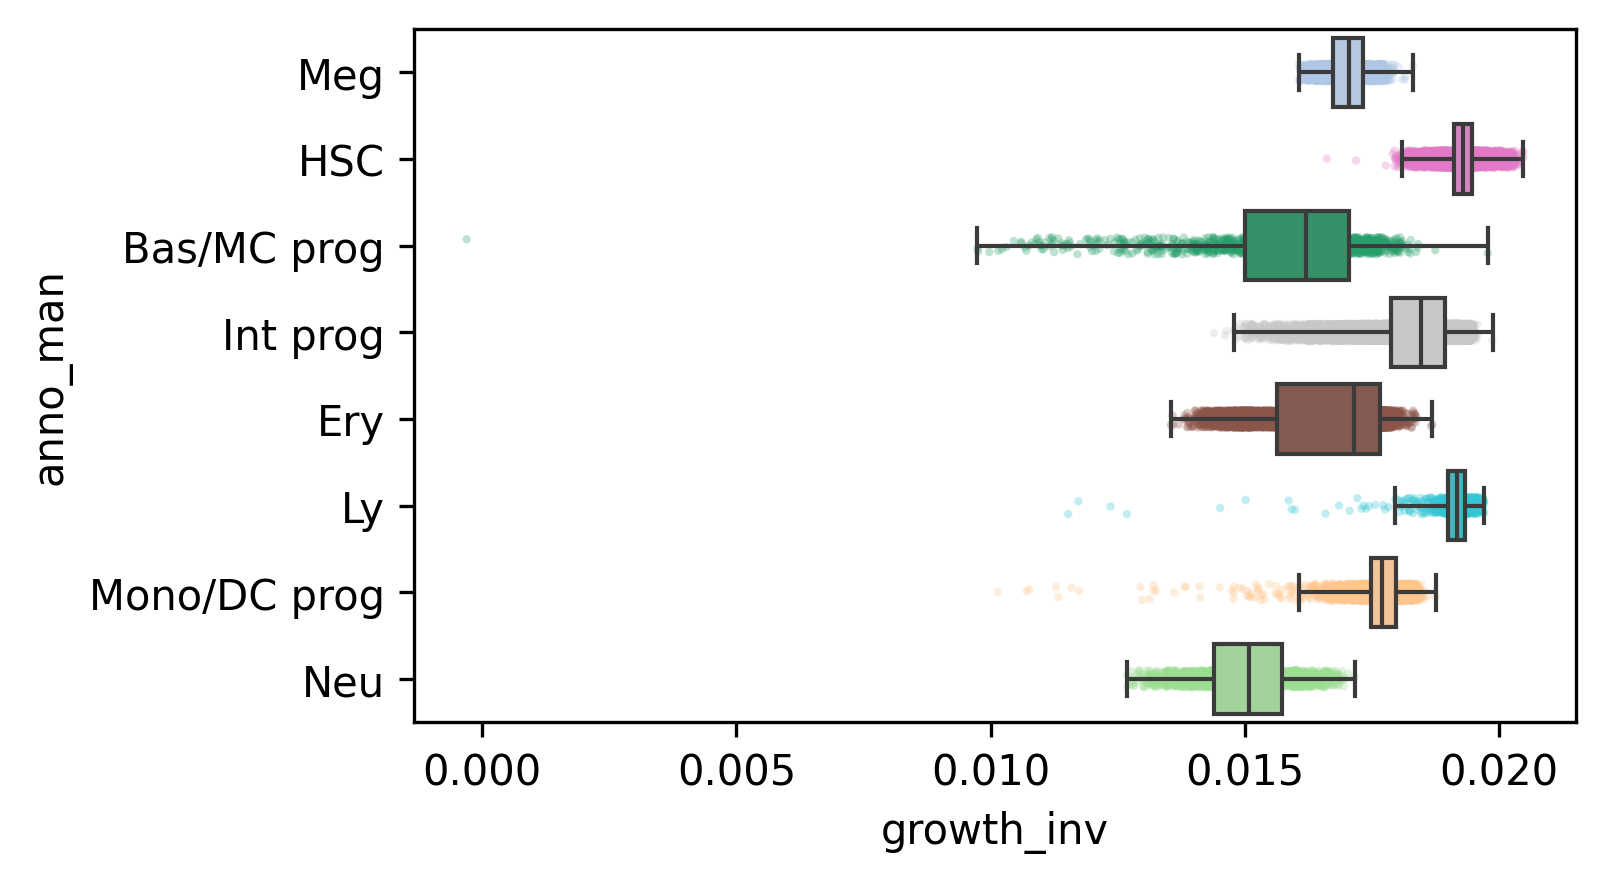

In [70]:
fig, ax = plt.subplots(figsize=(5,3), dpi=300)

sns.stripplot(data=adata.obs.query("`anno_man`!='Eos'"), x='growth_inv', 
             y= 'anno_man',   ax=ax, size=2, alpha=0.3,
             order = ['Meg', 'HSC', 'Bas/MC prog', 'Int prog','Ery','Ly','Mono/DC prog','Neu'],
             palette=celltype_pallete, zorder=1)

sns.boxplot(data=adata.obs.query("`anno_man`!='Eos'"), x='growth_inv', 
             y= 'anno_man',   showfliers=False, ax=ax, whis=3,
             order = ['Meg', 'HSC', 'Bas/MC prog', 'Int prog','Ery','Ly','Mono/DC prog','Neu'],
             palette=celltype_pallete,zorder=10)
# ax.legend(bbox_to_anchor=[1,0.8])

/tmp/ipykernel_548830/3890588927.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=adata.obs.query("`anno_man`!='Eos'"), x='drift_norm_inv',
/tmp/ipykernel_548830/3890588927.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=adata.obs.query("`anno_man`!='Eos'"), x='drift_norm_inv',


<Axes: xlabel='drift_norm_inv', ylabel='anno_man'>

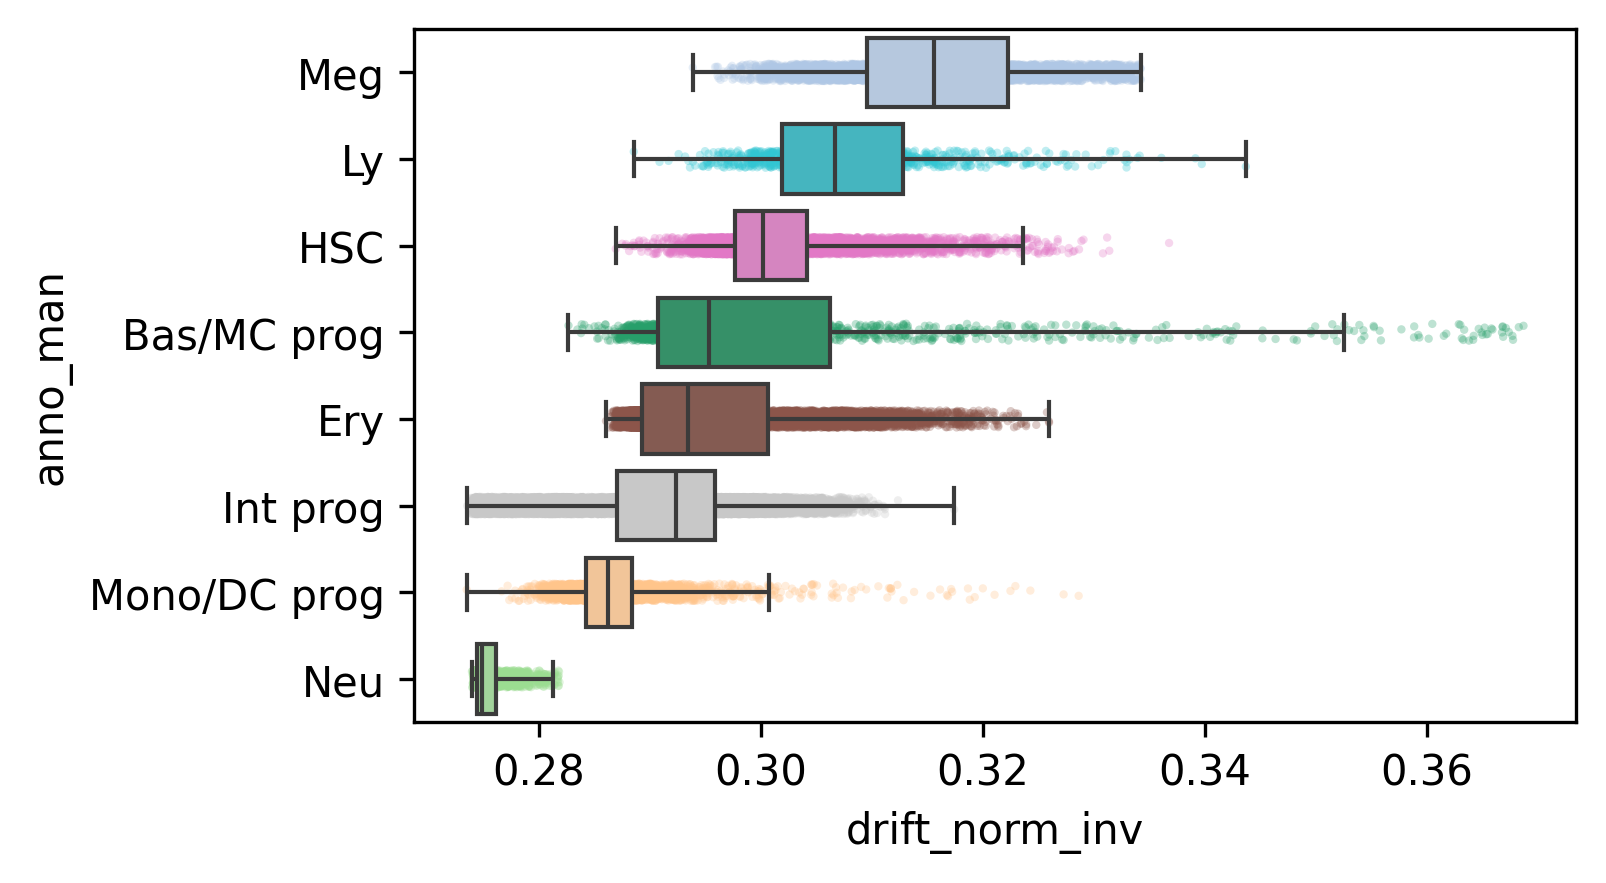

In [72]:
fig, ax = plt.subplots(figsize=(5,3), dpi=300)

sns.stripplot(data=adata.obs.query("`anno_man`!='Eos'"), x='drift_norm_inv', 
             y= 'anno_man',   ax=ax, size=2, alpha=0.3,
             order = ['Meg', 'Ly', 'HSC', 'Bas/MC prog', 'Ery', 'Int prog','Mono/DC prog','Neu'],
             palette=celltype_pallete, zorder=1)

sns.boxplot(data=adata.obs.query("`anno_man`!='Eos'"), x='drift_norm_inv', 
             y= 'anno_man',   showfliers=False, ax=ax, whis=3,
             order = ['Meg', 'Ly', 'HSC', 'Bas/MC prog', 'Ery', 'Int prog','Mono/DC prog','Neu'],
             palette=celltype_pallete,zorder=10)
# ax.legend(bbox_to_anchor=[1,0.8])

# growth with inv growth

In [75]:
g_df = adata.obs.groupby("timepoint_tx_days").agg({"growth_inv":'mean'}).reset_index()

In [85]:
dt = g_df['timepoint_tx_days'].values[1:] - 3
g = g_df['growth_inv'].values[1:]

np.exp(g*dt)

array([ 1.0433804 ,  1.09780981,  1.27433499,  1.53427117,  2.09294508,
        2.81181351,  4.68168801, 12.69175312])

In [91]:
fold = np.exp(np.diff(np.log(DS_full.popD['mean'])))

In [92]:
Dt = np.diff(DS_full.popD['t'])

In [93]:
g = np.log(fold) / Dt

In [ ]:
g

array([0.24305889, 0.07892835, 0.07758827, 0.02388656, 0.03590299,
       0.01464398, 0.00697838, 0.00697838])

# growth with time dependent model

In [47]:
pde_model = PINN.models.pde_params.load_from_checkpoint(
    "logs/tom_pos-DM_scaled_n[0, 1, 2, 3, 4, 6, 8]/pde_params_tsense/lightning_logs/version_4/checkpoints/epoch=95-total_loss=1.33532071.ckpt").to(device)

s = torch.from_numpy(DS_full.cellstate).float().to(device)
t = torch.from_numpy(adata.obs['timepoint_tx_days'].values).float().to(device) / 3

with torch.no_grad():
    g_t_dependent = pde_model.g(s,t)/ 3
    
adata.obs['growth_tv'] = g_t_dependent.cpu().numpy()

/ssd/users/Wergillius/miniforge3/envs/PINN_torch/lib/python3.9/site-packages/pytorch_lightning/utilities/migration/utils.py:49: PossibleUserWarning: The loaded checkpoint was produced with Lightning v2.3.0, which is newer than your current Lightning version: v1.9.5
  rank_zero_warn(


In [48]:
adata.obs['growth_tv'].max()

0.376849

In [49]:
tv_g_df = adata.obs.groupby(["timepoint_tx_days","anno_man"]).agg({"growth_tv":'mean'}).reset_index()

In [71]:
inv_param.head()

,anno_man,timepoint_tx_days,growth_inv,batch
36,Int prog,3,0.018824,199
27,HSC,3,0.019712,138
54,Meg,3,0.017161,29
37,Int prog,7,0.018614,270
28,HSC,7,0.019666,177


In [106]:
tv_g_df.tail(27)

,timepoint_tx_days,anno_man,growth_tv
54,112,Bas/MC prog,0.112493
55,112,Eos,NaN
56,112,Ery,0.122922
57,112,HSC,0.109086
58,112,Int prog,0.109648
59,112,Ly,0.102715
60,112,Meg,0.118078
61,112,Mono/DC prog,0.105501
62,112,Neu,0.112879
63,161,Bas/MC prog,0.103775


In [ ]:
dt = g_df['timepoint_tx_days'].values[1:] - 3
g = g_df['growth_tv'].values[1:]

np.exp(g*dt)

KeyError: 'growth_inv'

In [40]:
# the total number of cell 

# proportion
cell_type_prop = adata.obs.groupby('timepoint_tx_days')['anno_man'].value_counts(normalize=True).reset_index()

In [41]:
ncell_lookup = dict(zip(adata.uns['pop']['t'], adata.uns['pop']['mean']))

In [ ]:
cell_type_prop['n_cell'] = cell_type_prop['timepoint_tx_days'].map(ncell_lookup)

cell_type_prop['pop_size_ct'] = cell_type_prop.apply(
    lambda x : x['proportion'] * x['n_cell'], axis=1
)

cell_type_prop['pop_size_ct']

0       74.246193
1       51.487310
2       10.819797
3        4.104061
4        2.984772
         ...     
76    3343.909515
77    1836.367858
78    1168.597728
79     872.654147
80       2.529432
Name: pop_size_ct, Length: 81, dtype: float64

In [59]:
cell_type_prop

,timepoint_tx_days,anno_man,proportion,n_cell,pop_size_ct
0,3,Int prog,0.505076,147.00000,74.246193
1,3,HSC,0.350254,147.00000,51.487310
2,3,Meg,0.073604,147.00000,10.819797
3,3,Mono/DC prog,0.027919,147.00000,4.104061
4,3,Ery,0.020305,147.00000,2.984772
...,...,...,...,...,...
76,269,Mono/DC prog,0.080145,41722.98597,3343.909515
77,269,Neu,0.044013,41722.98597,1836.367858
78,269,Bas/MC prog,0.028008,41722.98597,1168.597728
79,269,Ly,0.020915,41722.98597,872.654147


In [81]:
inv_param = adata.obs.groupby(['anno_man', 'timepoint_tx_days']).agg({"growth_inv":'mean', 'batch':'count'}).reset_index()
inv_param = inv_param.sort_values('timepoint_tx_days')

In [82]:
inv_param

,anno_man,timepoint_tx_days,growth_inv,batch
0,Bas/MC prog,3,0.012637,1
36,Int prog,3,0.018824,199
45,Ly,3,0.018781,3
27,HSC,3,0.019712,138
54,Meg,3,0.017161,29
...,...,...,...,...
17,Eos,269,0.016538,1
62,Meg,269,0.017040,1348
35,HSC,269,0.019139,1943
44,Int prog,269,0.018303,7047


In [109]:
# population growth with g
intgration = []
dts = np.diff(adata.uns['pop']['t'])

for i,t in enumerate(adata.uns['pop']['t'][:-1]):
    dt = dts[i]
    tp1 = adata.uns['pop']['t'][i+1]
    for ct in ['HSC','Ery', 'Meg', 'Mono/DC prog', 'Neu']:

        N_start = cell_type_prop.query("`timepoint_tx_days`==@t & `anno_man`==@ct")['pop_size_ct'].item()
        g_inv = inv_param.query("`timepoint_tx_days`==@t & `anno_man`==@ct")['growth_inv'].item()
        g_tv = tv_g_df.query("`timepoint_tx_days`==@t & `anno_man`==@ct")['growth_tv'].item()

        N_end_tv = np.exp(g_tv*dt)*N_start
        N_end_inv = np.exp(g_inv*dt)*N_start
        N_obs_next = cell_type_prop.query("`timepoint_tx_days`==@tp1 & `anno_man`==@ct")['pop_size_ct'].item()

        row = {'starting_cell':N_start, 'g_inv':g_inv, 'g_tv':g_tv,
               'Ending_cell_tv':np.log10(N_end_tv), "Ending_cell_inv": np.log10(N_end_inv),
               "timepoint_tx_days":str(t) , 'anno_man':ct , "observed" : np.log10(N_obs_next)
               }

        intgration.append(row)

In [110]:
int_data = pd.json_normalize(intgration)
int_data.head()

,starting_cell,g_inv,g_tv,Ending_cell_tv,Ending_cell_inv,timepoint_tx_days,anno_man,observed
0,51.487310,0.019712,0.004214,1.719021,1.745944,3,HSC,2.036123
1,2.984772,0.017481,0.221885,0.860365,0.505279,3,Ery,1.495720
2,10.819797,0.017161,0.255168,1.477492,1.064031,3,Meg,1.737540
3,4.104061,0.017346,0.069124,0.733294,0.643348,3,Mono/DC prog,1.043423
4,1.865482,0.014935,0.356187,0.889552,0.296735,3,Neu,0.902094


<Axes: xlabel='timepoint_tx_days', ylabel='Ending_cell_tv'>

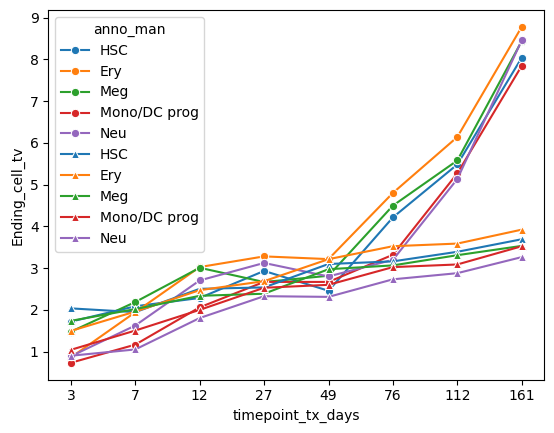

In [114]:
sns.lineplot(data=int_data, x='timepoint_tx_days', y='Ending_cell_tv', hue='anno_man',  marker='o')
sns.lineplot(data=int_data, x='timepoint_tx_days', y='observed', hue='anno_man', marker='^')

In [ ]:
sns.lineplot(data=int_data, x='timepoint_tx_days', y='Ending_cell_inv', hue='anno_man')